In [ ]:
# Méthode A : Téléversement manuel
from google.colab import files
import zipfile
import os

print("📤 Étape 1 : Téléverse ton fichier zip")
uploaded = files.upload()  # Interface graphique s'ouvre

print("📦 Étape 2 : Décompression")
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/dataset')
        print(f"Décompressé : {filename}")

dataset_path = '/content/dataset/Art'
print(f"✅ Chemin des données : {dataset_path}")

📤 Étape 1 : Téléverse ton fichier zip


Saving archive.zip to archive.zip
📦 Étape 2 : Décompression
Décompressé : archive.zip
✅ Chemin des données : /content/dataset/Art


In [ ]:
# =====================================================
# CELLULE 1 : CONFIGURATION ET IMPORTS
# =====================================================
# Exécutez cette cellule en premier pour configurer l'environnement

import math
import os
import logging
from typing import Tuple, Dict, Any, Optional

# --- Bibliothèques standards du ML ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ViT_B_16_Weights

# --- Utilitaires ---
from tqdm import tqdm
import cloudpickle

# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

# Configuration globale
class Config:
    """Conteneur pour tous les hyperparamètres et chemins."""
    # --- Chemins des données (déjà extraites) ---
    DATASET_PATH: str = '/content/dataset/Art'
    HUMAN_DIR: str = 'RealArt'
    AI_DIR: str = 'AiArtData'

    # --- Paramètres de données ---
    TEST_SIZE: float = 0.2
    RANDOM_SEED: int = 42
    BATCH_SIZE: int = 32
    IMG_SIZE: int = 224  # Taille d'entrée pour ViT
    NUM_WORKERS: int = 2  # Pour le chargement parallèle

    # --- Paramètres du modèle ---
    LEARNING_RATE: float = 1e-4
    WEIGHT_DECAY: float = 1e-5
    NUM_EPOCHS: int = 5
    DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Normalisation ViT (ImageNet) ---
    MEAN: Tuple[float, ...] = [0.485, 0.456, 0.406]
    STD: Tuple[float, ...] = [0.229, 0.224, 0.225]

config = Config()
logger.info(f"✅ Configuration chargée. Device: {config.DEVICE}")

In [ ]:
# =====================================================
# CELLULE 2 : CHARGEMENT DES DONNÉES
# =====================================================
# Exécutez cette cellule pour charger les chemins des images

def load_data_paths(config: Config) -> pd.DataFrame:
    """
    Construit un DataFrame avec les chemins d'accès aux images et leurs labels.
    """
    human_dir = os.path.join(config.DATASET_PATH, config.HUMAN_DIR)
    ai_dir = os.path.join(config.DATASET_PATH, config.AI_DIR)

    # Vérification que les dossiers existent
    if not os.path.exists(human_dir):
        raise FileNotFoundError(f"Dossier non trouvé : {human_dir}")
    if not os.path.exists(ai_dir):
        raise FileNotFoundError(f"Dossier non trouvé : {ai_dir}")

    data = []
    # 0 pour l'art humain
    for filename in os.listdir(human_dir):
        data.append([os.path.join(human_dir, filename), 0])
    # 1 pour l'art IA
    for filename in os.listdir(ai_dir):
        data.append([os.path.join(ai_dir, filename), 1])

    df = pd.DataFrame(data, columns=['path', 'label'])
    logger.info(f"📊 Dataset chargé : {len(df)} images")
    logger.info(f"   Distribution : {df['label'].value_counts().to_dict()}")
    return df

# Chargement des données
df = load_data_paths(config)
df.head()

,path,label
0,/content/dataset/Art/RealArt/beautiful-scenery...,0
1,/content/dataset/Art/RealArt/pexels-photo-4158...,0
2,/content/dataset/Art/RealArt/10-tips-for-stunn...,0
3,/content/dataset/Art/RealArt/spider-monkey-gty...,0
4,/content/dataset/Art/RealArt/beautiful-scenery...,0


In [ ]:
# =====================================================
# CELLULE 3 : DATASET PERSONNALISÉ PYTORCH
# =====================================================

class ImageDataset(Dataset):
    """Dataset PyTorch personnalisé pour charger les images."""
    def __init__(self, dataframe: pd.DataFrame, transform: transforms.Compose):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, label = self.dataframe.iloc[idx]
        from PIL import Image
        try:
            image = Image.open(img_path).convert('RGB')
            image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            logger.error(f"Erreur lors du chargement de {img_path}: {e}")
            # Retourner un tensor de remplacement (image noire)
            dummy_image = torch.zeros(3, config.IMG_SIZE, config.IMG_SIZE)
            return dummy_image, torch.tensor(label, dtype=torch.long)


EDA - Aperçu du dataset

📋 Aperçu des données :
                                                path  label
0  /content/dataset/Art/RealArt/beautiful-scenery...      0
1  /content/dataset/Art/RealArt/pexels-photo-4158...      0
2  /content/dataset/Art/RealArt/10-tips-for-stunn...      0
3  /content/dataset/Art/RealArt/spider-monkey-gty...      0
4  /content/dataset/Art/RealArt/beautiful-scenery...      0

📊 Distribution des classes :
label
1    539
0    436
Name: count, dtype: int64
   (0: Human Art, 1: AI Art)


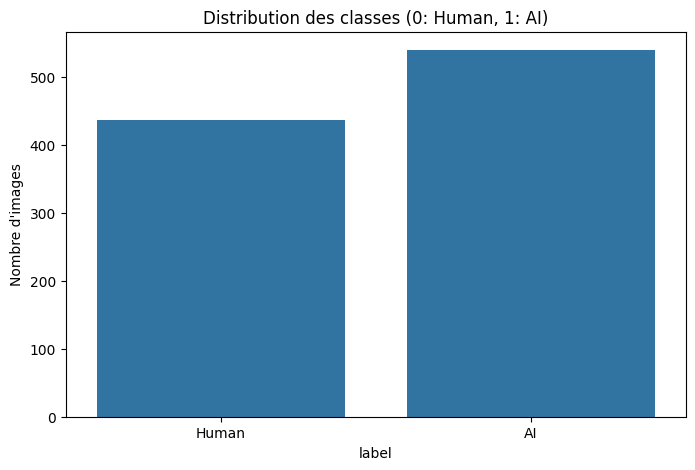

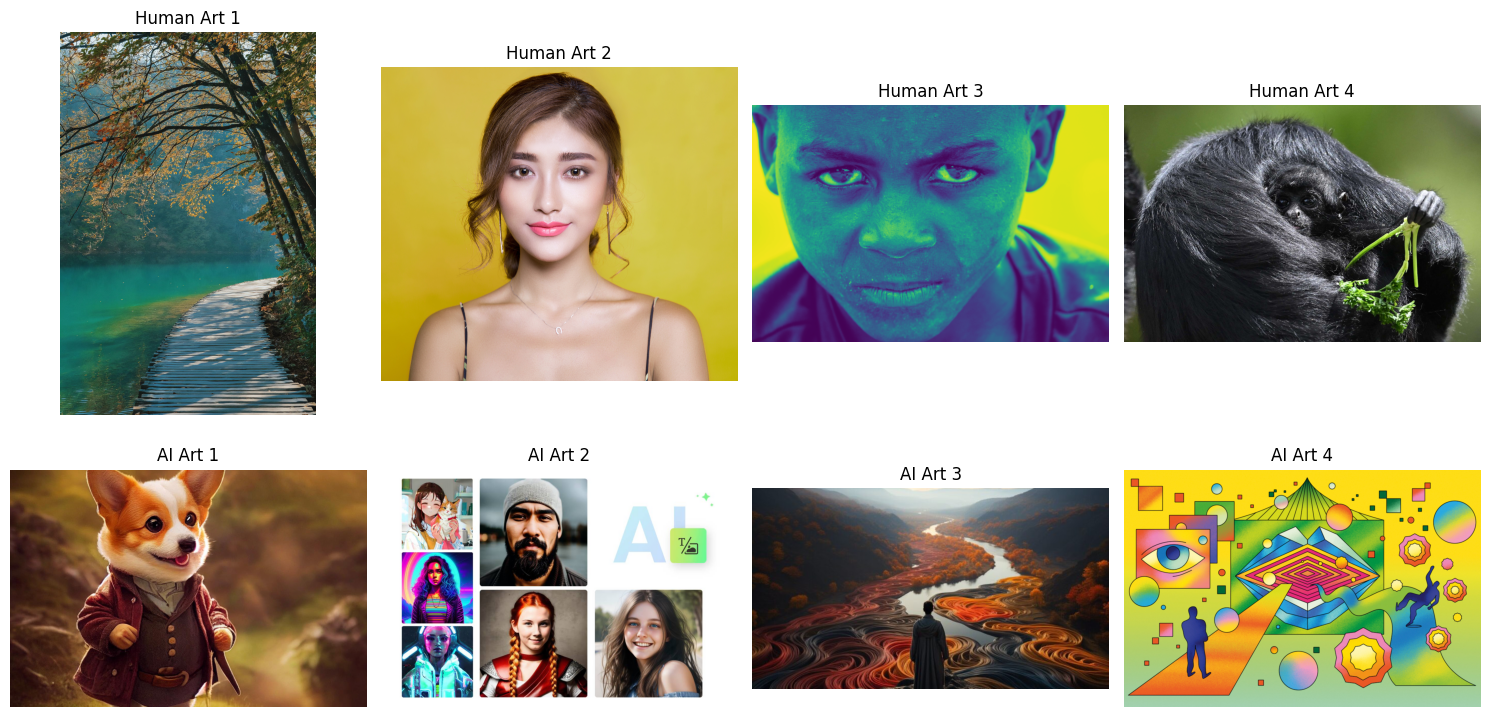

In [ ]:
# =====================================================
# CELLULE 4 : ANALYSE EXPLORATOIRE (EDA)
# =====================================================

def perform_eda(df: pd.DataFrame) -> None:
    """
    Effectue une analyse exploratoire simple.
    """
    logger.info("🔍 Analyse exploratoire des données")
    print("\n" + "="*50)
    print("EDA - Aperçu du dataset")
    print("="*50)
    print("\n📋 Aperçu des données :")
    print(df.head())

    print("\n📊 Distribution des classes :")
    print(df['label'].value_counts())
    print("   (0: Human Art, 1: AI Art)")

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='label')
    plt.title('Distribution des classes (0: Human, 1: AI)')
    plt.xticks([0, 1], ['Human', 'AI'])
    plt.ylabel('Nombre d\'images')
    plt.show()

    # Afficher quelques exemples d'images
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    for i in range(4):
        # Images humaines
        img_path = df[df['label'] == 0].iloc[i]['path']
        img = plt.imread(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Human Art {i+1}')
        axes[0, i].axis('off')

        # Images IA
        img_path = df[df['label'] == 1].iloc[i]['path']
        img = plt.imread(img_path)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'AI Art {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
    logger.info("✅ EDA terminée")

perform_eda(df)

In [ ]:
# =====================================================
# CELLULE 5 : PRÉPARATION DES DATALOADERS
# =====================================================

def prepare_dataloaders(config: Config, df: pd.DataFrame) -> Tuple[DataLoader, DataLoader, Dict[str, Any]]:
    """
    Prépare les DataLoaders d'entraînement et de test.
    """
    # Split train / test
    train_df, test_df = train_test_split(
        df, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED, shuffle=True
    )
    logger.info(f"Train size: {len(train_df)} images")
    logger.info(f"Test size: {len(test_df)} images")

    # Transformations
    transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=config.MEAN, std=config.STD),
    ])

    # Création des datasets
    train_dataset = ImageDataset(train_df, transform)
    test_dataset = ImageDataset(test_df, transform)

    # Création des dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if config.DEVICE.type == 'cuda' else False
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if config.DEVICE.type == 'cuda' else False
    )

    info = {
        'train_size': len(train_df),
        'test_size': len(test_df),
        'class_distribution': df['label'].value_counts().to_dict()
    }
    return train_loader, test_loader, info

# Préparation
train_loader, test_loader, info = prepare_dataloaders(config, df)
print(f"\n📊 Infos dataset : {info}")


📊 Infos dataset : {'train_size': 780, 'test_size': 195, 'class_distribution': {1: 539, 0: 436}}


In [ ]:
# =====================================================
# CELLULE 6 : CRÉATION DU MODÈLE VIT
# =====================================================

def create_vit_model(config: Config, num_classes: int = 2) -> nn.Module:
    """
    Crée et configure un modèle Vision Transformer pré-entraîné.
    """
    logger.info("🔄 Chargement du modèle Vision Transformer pré-entraîné...")
    weights = ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)

    # Remplacer la tête de classification
    num_features = model.heads.head.in_features
    model.heads.head = nn.Linear(num_features, num_classes)

    model = model.to(config.DEVICE)
    logger.info(f"✅ Modèle prêt. Paramètres: {sum(p.numel() for p in model.parameters()):,}")
    return model

model = create_vit_model(config)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 65.7MB/s]


In [ ]:
# =====================================================
# CELLULE 7 : FONCTIONS D'ENTRAÎNEMENT
# =====================================================

def train_one_epoch(model: nn.Module, loader: DataLoader,
                    optimizer: optim.Optimizer, criterion: nn.Module,
                    config: Config) -> Tuple[float, float]:
    """
    Entraîne le modèle pour une époque.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Entraînement", leave=False)
    for images, labels in pbar:
        images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def evaluate(model: nn.Module, loader: DataLoader,
             criterion: nn.Module, config: Config) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """
    Évalue le modèle sur un ensemble de données.
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Évaluation", leave=False):
            images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


def train_model(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader,
                config: Config) -> Dict[str, Any]:
    """
    Boucle d'entraînement principale.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE,
                            weight_decay=config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    logger.info("🚀 Début de l'entraînement...")
    for epoch in range(1, config.NUM_EPOCHS + 1):
        logger.info(f"--- Époque {epoch}/{config.NUM_EPOCHS} ---")

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, config)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, config)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        logger.info(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        logger.info(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    logger.info("✅ Entraînement terminé.")
    return history

In [ ]:
# =====================================================
# CELLULE 8 : ENTRAÎNEMENT DU MODÈLE
# =====================================================
# ⚠️ Cette cellule peut prendre du temps à s'exécuter

history = train_model(model, train_loader, test_loader, config)

Entraînement:  68%|██████▊   | 17/25 [00:21<00:08,  1.10s/it, loss=0.4599]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Évaluation:  57%|█████▋    | 4/7 [00:04<00:02,  1.00it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Entraînement:  20%|██        | 5/25 [00:06<00:25,  1.28s/it, loss=0.2011]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Évaluation:  57%|█████▋    | 4/7 [00:04<00:03,  1.04s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Entraînement:  72%|███████▏  | 18/2

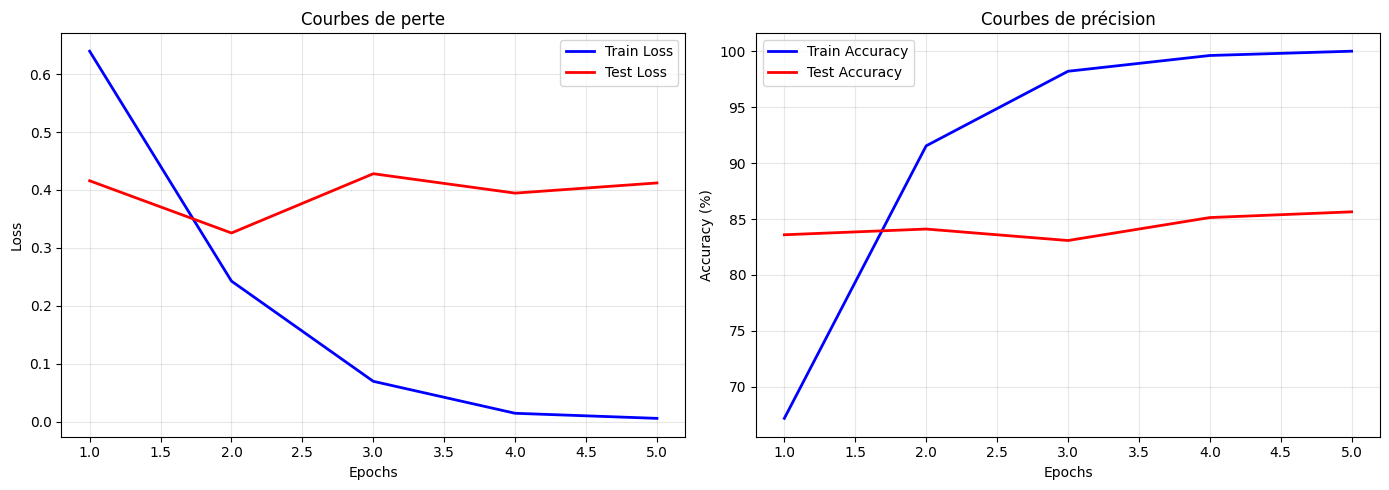

In [ ]:
# =====================================================
# CELLULE 9 : VISUALISATION DES RÉSULTATS
# =====================================================

def plot_training_history(history: Dict[str, list]) -> None:
    """Affiche les courbes de perte et de précision."""
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'r-', linewidth=2, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Courbes de perte')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', linewidth=2, label='Train Accuracy')
    plt.plot(epochs, history['test_acc'], 'r-', linewidth=2, label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title("Courbes de précision")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

Évaluation:  57%|█████▋    | 4/7 [00:05<00:03,  1.25s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
                                                         


 RÉSULTATS FINAUX - ÉVALUATION DÉTAILLÉE

📈 Précision finale sur le test : 85.64%
📉 Perte finale sur le test : 0.4121

------------------------------------------------------------
📊 RAPPORT DE CLASSIFICATION
------------------------------------------------------------
              precision    recall  f1-score   support

       Human       0.80      0.86      0.83        80
          AI       0.90      0.85      0.88       115

    accuracy                           0.86       195
   macro avg       0.85      0.86      0.85       195
weighted avg       0.86      0.86      0.86       195



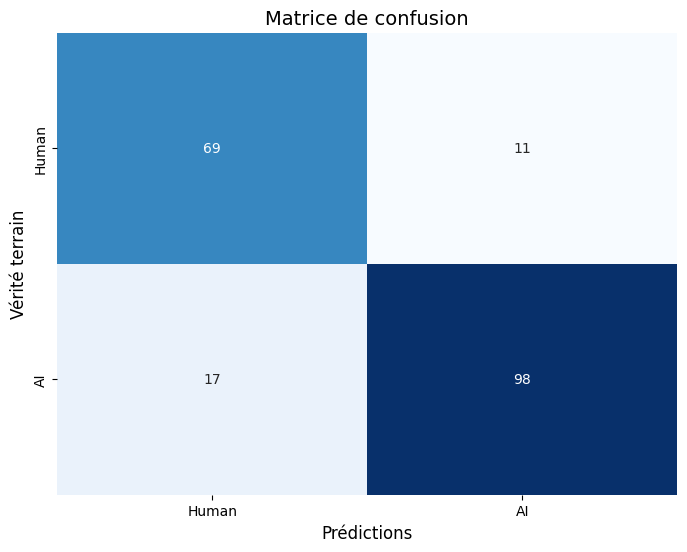


------------------------------------------------------------
📈 MÉTRIQUES BINAIRES (AI Art = 1)
------------------------------------------------------------
Précision (AI) : 0.8991
Rappel (AI) : 0.8522
F1-Score (AI) : 0.8750


In [ ]:
# =====================================================
# CELLULE 10 : ÉVALUATION FINALE DÉTAILLÉE
# =====================================================

def final_evaluation(model: nn.Module, test_loader: DataLoader, config: Config) -> None:
    """
    Évaluation complète avec métriques détaillées.
    """
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, config)

    print("\n" + "="*60)
    print(" RÉSULTATS FINAUX - ÉVALUATION DÉTAILLÉE")
    print("="*60)
    print(f"\n📈 Précision finale sur le test : {test_acc:.2f}%")
    print(f"📉 Perte finale sur le test : {test_loss:.4f}")

    print("\n" + "-"*60)
    print("📊 RAPPORT DE CLASSIFICATION")
    print("-"*60)
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    plt.xlabel('Prédictions', fontsize=12)
    plt.ylabel('Vérité terrain', fontsize=12)
    plt.title('Matrice de confusion', fontsize=14)
    plt.show()

    # Métriques détaillées
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    print("\n" + "-"*60)
    print("📈 MÉTRIQUES BINAIRES (AI Art = 1)")
    print("-"*60)
    print(f"Précision (AI) : {precision:.4f}")
    print(f"Rappel (AI) : {recall:.4f}")
    print(f"F1-Score (AI) : {f1:.4f}")

final_evaluation(model, test_loader, config)

In [ ]:
# =====================================================
# CELLULE 11 : SAUVEGARDE DU MODÈLE
# =====================================================

def save_model(model: nn.Module, history: Dict[str, list], config: Config, filename: str = "vit_ai_art_detector.pth") -> None:
    """
    Sauvegarde le modèle entraîné et son historique.
    """
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'history': history,
        'config': {
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'num_epochs': config.NUM_EPOCHS,
            'img_size': config.IMG_SIZE
        }
    }
    torch.save(checkpoint, filename)
    logger.info(f"✅ Modèle sauvegardé sous : {filename}")

    # Sauvegarde aussi l'historique au format CSV pour analyse
    history_df = pd.DataFrame(history)
    history_df.to_csv('training_history.csv', index=False)
    logger.info("✅ Historique sauvegardé sous : training_history.csv")

save_model(model, history, config)

In [ ]:
# =====================================================
# CELLULE 12 : FONCTION DE PRÉDICTION POUR NOUVELLES IMAGES
# =====================================================

def predict_image(model: nn.Module, image_path: str, config: Config) -> Tuple[int, float]:
    """
    Prédit la classe d'une nouvelle image.
    """
    from PIL import Image

    transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=config.MEAN, std=config.STD),
    ])

    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(config.DEVICE)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    return predicted_class, confidence

# Exemple d'utilisation (décommentez pour tester) :
# test_image_path = df[df['label'] == 1].iloc[0]['path']
# pred_class, confidence = predict_image(model, test_image_path, config)
# print(f"Prédiction : {'AI' if pred_class == 1 else 'Human'} (confiance: {confidence:.2%})")

In [ ]:
# =====================================================
# CELLULE 13 : RÉSUMÉ FINAL
# =====================================================

print("\n" + "="*60)
print("🎯 RÉSUMÉ DU PIPELINE")
print("="*60)
print(f"""
📊 DATASET
   - Total images : {len(df)}
   - Distribution : {df['label'].value_counts().to_dict()}

⚙️ CONFIGURATION
   - Device : {config.DEVICE}
   - Batch size : {config.BATCH_SIZE}
   - Learning rate : {config.LEARNING_RATE}
   - Epochs : {config.NUM_EPOCHS}

📈 RÉSULTATS FINAUX
   - Précision test : {history['test_acc'][-1]:.2f}%
   - Perte test : {history['test_loss'][-1]:.4f}

💾 FICHIERS SAUVEGARDÉS
   - Modèle : vit_ai_art_detector.pth
   - Historique : training_history.csv
""")
print("="*60)


🎯 RÉSUMÉ DU PIPELINE

📊 DATASET
   - Total images : 975
   - Distribution : {1: 539, 0: 436}

⚙️ CONFIGURATION
   - Device : cuda
   - Batch size : 32
   - Learning rate : 0.0001
   - Epochs : 5

📈 RÉSULTATS FINAUX
   - Précision test : 85.64%
   - Perte test : 0.4121

💾 FICHIERS SAUVEGARDÉS
   - Modèle : vit_ai_art_detector.pth
   - Historique : training_history.csv



In [ ]:
# =====================================================
# CELLULE CORRIGÉE : CHARGEMENT DU MODÈLE AVEC weights_only=False
# =====================================================

import os
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ViT_B_16_Weights
import numpy as np

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé : {DEVICE}")

# Chemin du modèle
model_path = "/content/vit_ai_art_detector.pth"
print(f"📁 Chargement de : {model_path}")

try:
    # Tentative de chargement avec weights_only=True (sécurisé)
    print("🔄 Tentative de chargement sécurisé (weights_only=True)...")
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=True)
    print("✅ Chargement sécurisé réussi !")

except Exception as e:
    print(f"⚠️  Échec du chargement sécurisé : {type(e).__name__}")
    print("🔄 Tentative de chargement avec weights_only=False (moins sécurisé)...")
    print("   ⚠️  Cette méthode est acceptable car le fichier provient de votre propre entraînement.")

    # Chargement avec weights_only=False (comportement avant PyTorch 2.6)
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    print("✅ Modèle chargé avec weights_only=False")

# Créer le modèle avec la même architecture
print("\n🔄 Création du modèle ViT...")
weights = ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 2)

# Charger les poids
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print("   Modèle chargé depuis checkpoint (clé 'model_state_dict')")
else:
    model.load_state_dict(checkpoint)
    print("   Modèle chargé (state_dict direct)")

model = model.to(DEVICE)
model.eval()

# Afficher les informations disponibles
print("\n📊 INFORMATIONS DU CHECKPOINT")
print("-" * 40)
for key in checkpoint.keys():
    if key != 'model_state_dict':
        if key == 'history':
            if 'test_acc' in checkpoint['history']:
                final_acc = checkpoint['history']['test_acc'][-1]
                print(f"   Précision test finale: {final_acc:.2f}%")
            if 'train_loss' in checkpoint['history']:
                print(f"   Époques: {len(checkpoint['history']['train_loss'])}")
        elif key == 'config':
            print(f"   Configuration: {checkpoint['config']}")
        else:
            print(f"   {key}: présent")

print("\n✅ Modèle prêt pour l'évaluation !")

✅ Device utilisé : cuda
📁 Chargement de : /content/vit_ai_art_detector.pth
🔄 Tentative de chargement sécurisé (weights_only=True)...
⚠️  Échec du chargement sécurisé : UnpicklingError
🔄 Tentative de chargement avec weights_only=False (moins sécurisé)...
   ⚠️  Cette méthode est acceptable car le fichier provient de votre propre entraînement.
✅ Modèle chargé avec weights_only=False

🔄 Création du modèle ViT...
   Modèle chargé depuis checkpoint (clé 'model_state_dict')

📊 INFORMATIONS DU CHECKPOINT
----------------------------------------
   Précision test finale: 85.64%
   Époques: 5
   Configuration: {'batch_size': 32, 'learning_rate': 0.0001, 'num_epochs': 5, 'img_size': 224}

✅ Modèle prêt pour l'évaluation !


In [ ]:
# =====================================================
# CELLULE : VÉRIFICATION DU MODÈLE CHARGÉ
# =====================================================

# Vérifier que le modèle est bien chargé
if 'model' in globals() and model is not None:
    print("✅ Modèle chargé avec succès !")
    print(f"   Architecture: {model.__class__.__name__}")

    # Compter les paramètres
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Paramètres totaux: {total_params:,}")
    print(f"   Paramètres entraînables: {trainable_params:,}")

    # Test avec une entrée factice
    dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        output = model(dummy_input)
    print(f"   Shape de sortie: {output.shape}")
    print(f"   Test de forward réussi ✓")

else:
    print("❌ Modèle non chargé. Exécutez d'abord la cellule précédente.")

✅ Modèle chargé avec succès !
   Architecture: VisionTransformer
   Paramètres totaux: 85,800,194
   Paramètres entraînables: 85,800,194
   Shape de sortie: torch.Size([1, 2])
   Test de forward réussi ✓


🔍 ÉVALUATION SUR LE TEST SET


Évaluation:  57%|█████▋    | 4/7 [00:03<00:02,  1.11it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Évaluation: 100%|██████████| 7/7 [00:06<00:00,  1.09it/s]



📊 Précision globale : 85.64%

📈 RAPPORT DE CLASSIFICATION
----------------------------------------
              precision    recall  f1-score   support

      Humain       0.86      0.80      0.83        86
          IA       0.85      0.90      0.88       109

    accuracy                           0.86       195
   macro avg       0.86      0.85      0.85       195
weighted avg       0.86      0.86      0.86       195



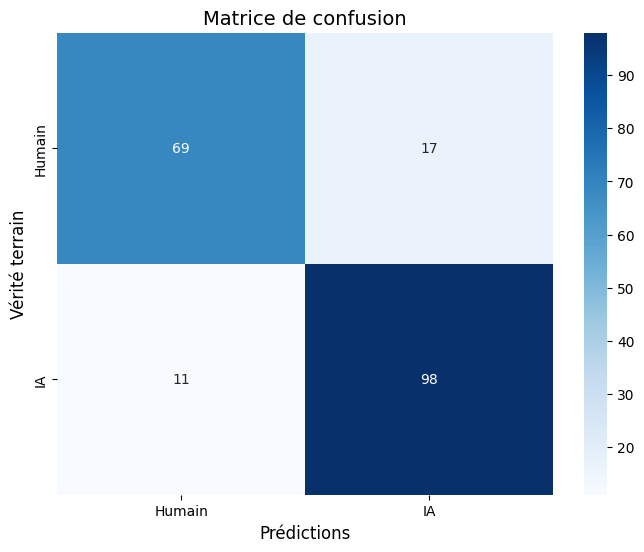


📊 MÉTRIQUES DÉTAILLÉES (Classe IA)
----------------------------------------
Précision : 0.8522
Rappel    : 0.8991
F1-Score  : 0.8750


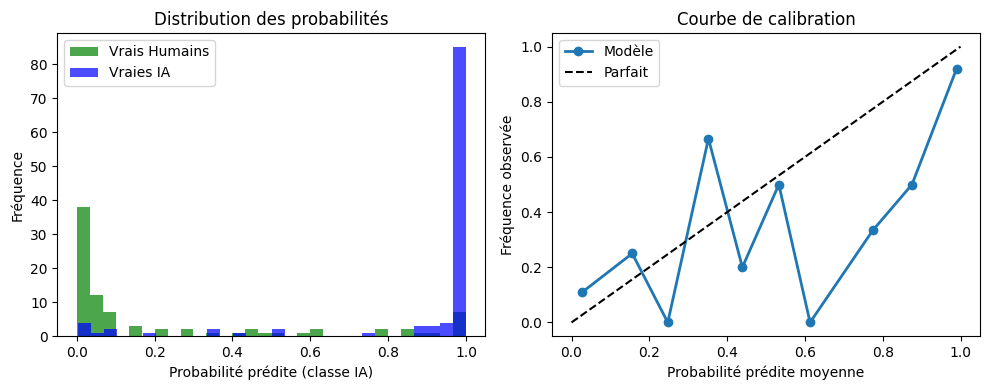

In [ ]:
# =====================================================
# CELLULE : ÉVALUATION SUR LE TEST SET
# =====================================================

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

def evaluate_model(model, test_loader, device):
    """
    Évalue le modèle sur l'ensemble de test.
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Évaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Vérifier que le modèle et les dataloaders sont disponibles
if 'model' in globals() and model is not None and 'test_loader' in globals():
    print("🔍 ÉVALUATION SUR LE TEST SET")
    print("=" * 60)

    # Obtenir les prédictions
    y_true, y_pred, y_probs = evaluate_model(model, test_loader, DEVICE)

    # Calculer la précision
    accuracy = np.mean(y_true == y_pred)
    print(f"\n📊 Précision globale : {accuracy:.2%}")

    # Rapport de classification
    print("\n📈 RAPPORT DE CLASSIFICATION")
    print("-" * 40)
    print(classification_report(y_true, y_pred, target_names=['Humain', 'IA']))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Humain', 'IA'], yticklabels=['Humain', 'IA'])
    plt.xlabel('Prédictions', fontsize=12)
    plt.ylabel('Vérité terrain', fontsize=12)
    plt.title('Matrice de confusion', fontsize=14)
    plt.show()

    # Métriques détaillées
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n📊 MÉTRIQUES DÉTAILLÉES (Classe IA)")
    print("-" * 40)
    print(f"Précision : {precision:.4f}")
    print(f"Rappel    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # Distribution des probabilités
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(y_probs[y_true == 0, 1], bins=30, alpha=0.7, label='Vrais Humains', color='green')
    plt.hist(y_probs[y_true == 1, 1], bins=30, alpha=0.7, label='Vraies IA', color='blue')
    plt.xlabel('Probabilité prédite (classe IA)')
    plt.ylabel('Fréquence')
    plt.title('Distribution des probabilités')
    plt.legend()

    plt.subplot(1, 2, 2)
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_probs[:, 1], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modèle')
    plt.plot([0, 1], [0, 1], 'k--', label='Parfait')
    plt.xlabel('Probabilité prédite moyenne')
    plt.ylabel('Fréquence observée')
    plt.title('Courbe de calibration')
    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    print("❌ Modèle ou test_loader non disponible.")
    print("   Assurez-vous d'avoir exécuté :")
    print("   - La cellule de chargement du modèle")
    print("   - Les cellules de préparation des données (train_loader, test_loader)")

✅ Device utilisé : cuda
📤 Téléverse une image à tester


Saving Screenshot_20220308-160920_Gallery.jpg to Screenshot_20220308-160920_Gallery.jpg

🔍 Analyse de: Screenshot_20220308-160920_Gallery.jpg


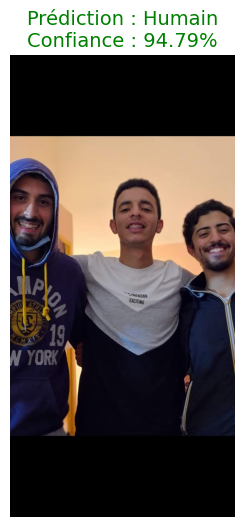

✅ Résultat : Humain (confiance: 94.79%)


In [ ]:
# =====================================================
# CELLULE : TEST AVEC UNE IMAGE TÉLÉVERSÉE
# =====================================================
# Exécutez cette cellule pour tester votre modèle avec une image

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Définir le device (important !)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé : {DEVICE}")

# Définir les transformations (identiques à l'entraînement)
data_transforms = {
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

def predict_image(image_path, model, device, transform):
    """
    Prédit la classe d'une image.
    """
    try:
        # Charger et prétraiter l'image
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        # Prédiction
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

        # Résultats
        class_names = ['Humain', 'IA']
        pred_class = class_names[predicted.item()]
        confidence = probabilities[0][predicted.item()].item()

        # Afficher l'image avec la prédiction
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        color = 'green' if predicted.item() == 0 else 'blue'
        plt.title(f"Prédiction : {pred_class}\nConfiance : {confidence:.2%}",
                 color=color, fontsize=14)
        plt.show()

        return pred_class, confidence, image

    except Exception as e:
        print(f"❌ Erreur lors de la prédiction : {e}")
        return None, None, None

# Téléverser une image
print("📤 Téléverse une image à tester")
uploaded = files.upload()

# Analyser chaque image téléversée
for filename in uploaded.keys():
    print(f"\n🔍 Analyse de: {filename}")
    prediction, confidence, img = predict_image(
        filename, model, DEVICE, data_transforms['val']
    )

    if prediction:
        print(f"✅ Résultat : {prediction} (confiance: {confidence:.2%})")

In [ ]:
# =====================================================
# CELLULE : SAUVEGARDE COMPLÈTE DU MODÈLE (CORRIGÉE)
# =====================================================

import torch
import os
from datetime import datetime

def save_complete_model(model, history, config, test_acc=None, filename="art_classifier_complete.pth"):
    """
    Sauvegarde le modèle avec toutes ses métadonnées.
    """
    # Créer le checkpoint
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'history': history,
        'config': {
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'num_epochs': config.NUM_EPOCHS,
            'img_size': config.IMG_SIZE,
            'model_architecture': 'ViT-B/16'
        },
        'final_train_acc': history['train_acc'][-1] if history and 'train_acc' in history else None,
        'final_test_acc': history['test_acc'][-1] if history and 'test_acc' in history else None,
        'saved_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    # Ajouter test_acc si fourni
    if test_acc is not None:
        checkpoint['evaluation_test_acc'] = test_acc

    # Sauvegarder
    torch.save(checkpoint, filename)
    print(f"✅ Modèle complet sauvegardé sous : {filename}")
    print(f"   - Précision finale train: {checkpoint['final_train_acc']:.2f}%" if checkpoint['final_train_acc'] else "   - Pas de données train")
    print(f"   - Précision finale test: {checkpoint['final_test_acc']:.2f}%" if checkpoint['final_test_acc'] else "   - Pas de données test")

    return checkpoint

# Sauvegarder le modèle
if 'model' in globals() and model is not None:
    # Récupérer test_acc si disponible
    test_acc = None
    if 'test_acc' in locals() or 'test_acc' in globals():
        test_acc = locals().get('test_acc', globals().get('test_acc'))

    checkpoint = save_complete_model(
        model=model,
        history=history if 'history' in globals() else None,
        config=config,
        test_acc=test_acc
    )
else:
    print("❌ Modèle non trouvé. Assurez-vous que le modèle est chargé.")

✅ Modèle complet sauvegardé sous : art_classifier_complete.pth
   - Précision finale train: 100.00%
   - Précision finale test: 85.64%


In [ ]:
# =====================================================
# CELLULE : CHARGEMENT DU MODÈLE COMPLET
# =====================================================

def load_complete_model(filename="art_classifier_complete.pth"):
    """
    Charge un modèle complet avec ses métadonnées.
    """
    if not os.path.exists(filename):
        print(f"❌ Fichier {filename} non trouvé")
        return None, None, None

    checkpoint = torch.load(filename, map_location=DEVICE, weights_only=False)

    # Recréer le modèle
    from torchvision.models import ViT_B_16_Weights
    weights = ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    num_features = model.heads.head.in_features
    model.heads.head = nn.Linear(num_features, 2)

    # Charger les poids
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(DEVICE)
    model.eval()

    print(f"✅ Modèle chargé depuis {filename}")
    print(f"   📅 Sauvegardé le: {checkpoint.get('saved_date', 'inconnue')}")
    print(f"   📊 Précision finale train: {checkpoint.get('final_train_acc', 'N/A')}")
    print(f"   📊 Précision finale test: {checkpoint.get('final_test_acc', 'N/A')}")

    return model, checkpoint.get('history'), checkpoint.get('config')

# Exemple de chargement
# model, history, config = load_complete_model("art_classifier_complete.pth")

In [ ]:
# =====================================================
# CELLULE 1 : INSTALLATION ET IMPORTS
# =====================================================
!pip install gradio -q

import gradio as gr
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ViT_B_16_Weights
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import logging
from typing import Tuple, Optional, Dict

# Configuration
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Configuration du device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé : {DEVICE}")

# Configuration (identique à l'entraînement)
class Config:
    IMG_SIZE: int = 224
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]
    DEVICE = DEVICE

config = Config()

✅ Device utilisé : cuda


In [ ]:
# =====================================================
# CELLULE 2 : CHARGEMENT DU MODÈLE ENTRAÎNÉ
# =====================================================

def load_trained_model(model_path: str = "art_classifier_complete.pth"):
    """
    Charge le modèle entraîné.
    """
    if not os.path.exists(model_path):
        print(f"❌ Fichier {model_path} non trouvé!")
        print("   Tentative avec vit_ai_art_detector.pth...")
        model_path = "vit_ai_art_detector.pth"

        if not os.path.exists(model_path):
            print("❌ Aucun modèle trouvé!")
            return None, None, None

    print(f"📁 Chargement du modèle : {model_path}")

    # Charger le checkpoint
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # Créer le modèle
    weights = ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    num_features = model.heads.head.in_features
    model.heads.head = nn.Linear(num_features, 2)

    # Charger les poids
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model = model.to(DEVICE)
    model.eval()

    # Récupérer les métadonnées
    history = checkpoint.get('history', None)
    config_dict = checkpoint.get('config', {})

    print(f"✅ Modèle chargé avec succès !")
    if history and 'test_acc' in history:
        print(f"   📊 Précision test: {history['test_acc'][-1]:.2f}%")

    return model, history, config_dict

# Charger le modèle
model, history, model_config = load_trained_model()

📁 Chargement du modèle : art_classifier_complete.pth
✅ Modèle chargé avec succès !
   📊 Précision test: 85.64%


In [ ]:
# =====================================================
# CELLULE 3 : FONCTIONS DE PRÉDICTION
# =====================================================

def preprocess_image(image: Image.Image) -> torch.Tensor:
    """
    Prétraite une image pour le modèle.
    """
    transform = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=config.MEAN, std=config.STD),
    ])

    image_tensor = transform(image).unsqueeze(0).to(DEVICE)
    return image_tensor

def predict(image) -> Tuple[str, float, Dict[str, float], Image.Image]:
    """
    Prédit si une image est de l'art IA ou humain.
    """
    if image is None:
        return "❌ Aucune image fournie", 0.0, {}, None

    try:
        # Prétraitement
        image_tensor = preprocess_image(image)

        # Prédiction
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            probs = probabilities[0].cpu().numpy()

            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = probs[predicted_class]

        # Résultat
        class_names = ['🖼️ Art Humain', '🤖 Art IA']
        result = class_names[predicted_class]

        # Dictionnaire des probabilités
        prob_dict = {
            'Humain': float(probs[0]),
            'IA': float(probs[1])
        }

        # Créer une image avec annotation pour l'affichage
        img_with_pred = image.copy()

        return result, float(confidence), prob_dict, img_with_pred

    except Exception as e:
        logger.error(f"Erreur lors de la prédiction: {e}")
        return f"❌ Erreur: {str(e)}", 0.0, {}, None

def predict_batch(files) -> pd.DataFrame:
    """
    Analyse plusieurs images en batch.
    """
    if not files:
        return pd.DataFrame()

    results = []
    for file in files:
        try:
            image = Image.open(file).convert('RGB')
            result, confidence, probs, _ = predict(image)

            results.append({
                'Fichier': os.path.basename(file),
                'Prédiction': result,
                'Confiance': f"{confidence:.2%}",
                'Probabilité Humain': f"{probs.get('Humain', 0):.2%}",
                'Probabilité IA': f"{probs.get('IA', 0):.2%}"
            })
        except Exception as e:
            results.append({
                'Fichier': os.path.basename(file),
                'Prédiction': f"❌ Erreur",
                'Confiance': "-",
                'Probabilité Humain': "-",
                'Probabilité IA': "-"
            })

    return pd.DataFrame(results)

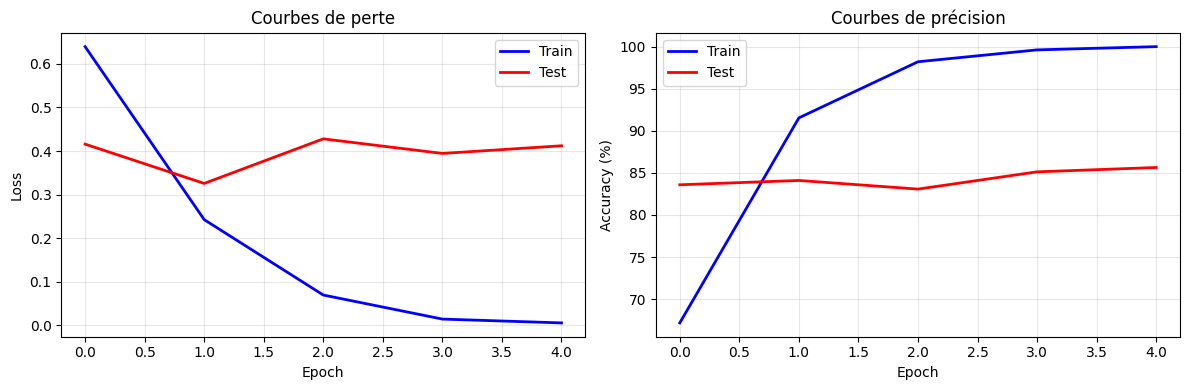

In [ ]:
# =====================================================
# CELLULE 4 : INTERFACE GRADIO (SANS CSS)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr

# Récupérer les valeurs de configuration
batch_size = config.BATCH_SIZE if hasattr(config, 'BATCH_SIZE') else 32
learning_rate = config.LEARNING_RATE if hasattr(config, 'LEARNING_RATE') else 0.0001
img_size = config.IMG_SIZE if hasattr(config, 'IMG_SIZE') else 224

def create_interface_no_css():
    """
    Crée l'interface Gradio complète (sans CSS pour éviter les erreurs).
    """
    with gr.Blocks(title="🎨 Détecteur d'Art IA vs Humain") as demo:

        # En-tête simple
        gr.Markdown(f"""
        # 🎨 Détecteur d'Art IA vs Humain

        Chargez une image pour déterminer si elle a été créée par un humain ou par une IA

        **📊 Précision du modèle: {history['test_acc'][-1]:.2f}%**
        ---
        """)

        with gr.Tabs():
            # Onglet 1 : Prédiction simple
            with gr.TabItem("🔍 Prédiction Simple"):
                with gr.Row():
                    with gr.Column(scale=1):
                        # Zone de téléchargement
                        input_image = gr.Image(
                            type="pil",
                            label="📤 Chargez votre image",
                            height=400
                        )

                        with gr.Row():
                            clear_btn = gr.Button("🗑️ Effacer", variant="secondary")
                            predict_btn = gr.Button("🚀 Analyser", variant="primary")

                    with gr.Column(scale=1):
                        # Résultat
                        result_text = gr.Textbox(
                            label="📊 Résultat",
                            lines=2
                        )

                        # Barre de progression pour la confiance
                        confidence_slider = gr.Slider(
                            label="Niveau de confiance",
                            minimum=0,
                            maximum=1,
                            value=0,
                            step=0.01,
                            interactive=False
                        )

                        # Graphique des probabilités
                        prob_plot = gr.BarPlot(
                            value=pd.DataFrame({
                                'Classe': ['Humain', 'IA'],
                                'Probabilité': [0.5, 0.5]
                            }),
                            x='Classe',
                            y='Probabilité',
                            title="Probabilités par classe",
                            color='Classe',
                            y_lim=[0, 1],
                            width=400,
                            height=300
                        )

                        # Image annotée
                        output_image = gr.Image(
                            label="Image analysée",
                            height=300
                        )

                # Gestion des événements
                def process_prediction(image):
                    if image is None:
                        return "❌ Aucune image", 0.0, pd.DataFrame({'Classe': ['Humain', 'IA'], 'Probabilité': [0.5, 0.5]}), None

                    result, confidence, probs, img = predict(image)

                    # Créer le dataframe pour le graphique
                    df_probs = pd.DataFrame({
                        'Classe': ['Humain', 'IA'],
                        'Probabilité': [probs['Humain'], probs['IA']]
                    })

                    return result, confidence, df_probs, img

                predict_btn.click(
                    fn=process_prediction,
                    inputs=input_image,
                    outputs=[result_text, confidence_slider, prob_plot, output_image]
                )

                def clear_all():
                    empty_df = pd.DataFrame({'Classe': ['Humain', 'IA'], 'Probabilité': [0.5, 0.5]})
                    return None, "", 0.0, empty_df, None

                clear_btn.click(
                    fn=clear_all,
                    outputs=[input_image, result_text, confidence_slider, prob_plot, output_image]
                )

            # Onglet 2 : Analyse par lot
            with gr.TabItem("📁 Analyse par Lot"):
                with gr.Row():
                    with gr.Column():
                        batch_input = gr.File(
                            file_count="multiple",
                            label="📤 Sélectionnez plusieurs images",
                            file_types=["image", ".png", ".jpg", ".jpeg"]
                        )

                        batch_btn = gr.Button("📊 Analyser le lot", variant="primary")

                    with gr.Column():
                        batch_output = gr.Dataframe(
                            label="📋 Résultats",
                            headers=["Fichier", "Prédiction", "Confiance", "Probabilité Humain", "Probabilité IA"],
                            interactive=False
                        )

                batch_btn.click(
                    fn=predict_batch,
                    inputs=batch_input,
                    outputs=batch_output
                )

            # Onglet 3 : Statistiques du modèle
            with gr.TabItem("📊 Statistiques"):
                with gr.Row():
                    with gr.Column():
                        gr.Markdown(f"""
                        ### 📈 Performance du modèle

                        | Métrique | Valeur |
                        |----------|--------|
                        | **Précision test** | {history['test_acc'][-1]:.2f}% |
                        | **Perte test** | {history['test_loss'][-1]:.4f} |
                        | **Époques** | {len(history['train_loss'])} |

                        ### ⚙️ Configuration
                        | Paramètre | Valeur |
                        |-----------|--------|
                        | **Batch size** | {batch_size} |
                        | **Learning rate** | {learning_rate} |
                        | **Taille d'image** | {img_size}x{img_size} |
                        | **Device** | {DEVICE} |
                        """)

                    with gr.Column():
                        # Graphique d'historique
                        if history:
                            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

                            ax1.plot(history['train_loss'], label='Train', linewidth=2, color='blue')
                            ax1.plot(history['test_loss'], label='Test', linewidth=2, color='red')
                            ax1.set_xlabel('Epoch')
                            ax1.set_ylabel('Loss')
                            ax1.set_title('Courbes de perte')
                            ax1.legend()
                            ax1.grid(True, alpha=0.3)

                            ax2.plot(history['train_acc'], label='Train', linewidth=2, color='blue')
                            ax2.plot(history['test_acc'], label='Test', linewidth=2, color='red')
                            ax2.set_xlabel('Epoch')
                            ax2.set_ylabel('Accuracy (%)')
                            ax2.set_title('Courbes de précision')
                            ax2.legend()
                            ax2.grid(True, alpha=0.3)

                            plt.tight_layout()
                            gr.Plot(fig)

            # Onglet 4 : Exemples
            with gr.TabItem("🖼️ Exemples"):
                gr.Markdown("""
                ### 🖼️ Exemples d'images à tester

                Vous pouvez utiliser ces types d'images pour tester le détecteur :

                - **Art Humain** : Peintures classiques, photographies, dessins traditionnels
                - **Art IA** : Images générées par DALL-E, Midjourney, Stable Diffusion
                """)

                # Afficher quelques exemples du dataset si disponibles
                if os.path.exists('/content/dataset/Art/RealArt'):
                    human_examples = os.listdir('/content/dataset/Art/RealArt')[:2]
                    ai_examples = os.listdir('/content/dataset/Art/AiArtData')[:2]

                    if human_examples:
                        gr.Markdown("#### 🖼️ Exemples d'art humain")
                        with gr.Row():
                            for ex in human_examples:
                                gr.Image(f'/content/dataset/Art/RealArt/{ex}', height=200)

                    if ai_examples:
                        gr.Markdown("#### 🤖 Exemples d'art IA")
                        with gr.Row():
                            for ex in ai_examples:
                                gr.Image(f'/content/dataset/Art/AiArtData/{ex}', height=200)

    return demo

# Créer l'interface
demo_no_css = create_interface_no_css()

In [ ]:
# =====================================================
# CELLULE 5 : LANCEMENT DE L'INTERFACE (SANS CSS)
# =====================================================

print("🚀 Démarrage de l'interface Gradio...")
print("📝 L'interface sera accessible via l'URL ci-dessous")
print("⏳ Patientez quelques secondes...\n")

demo_no_css.launch(
    share=True,           # Crée un lien public partageable
    debug=False,
    server_name="0.0.0.0"
    # Paramètre CSS supprimé
)

🚀 Démarrage de l'interface Gradio...
📝 L'interface sera accessible via l'URL ci-dessous
⏳ Patientez quelques secondes...

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://942375e39131670d44.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# =====================================================
# CELLULE 6 : VERSION SIMPLIFIÉE (LA PLUS FIABLE)
# =====================================================

# Interface ultra-simplifiée qui fonctionne à tous les coups
def predict_minimal(image):
    """Version minimale de prédiction."""
    if image is None:
        return "Veuillez charger une image"

    result, confidence, probs, _ = predict(image)
    return f"{result}\nConfiance: {confidence:.1%}\nHumain: {probs['Humain']:.1%}, IA: {probs['IA']:.1%}"

minimal_interface = gr.Interface(
    fn=predict_minimal,
    inputs=gr.Image(type="pil", label="📤 Image"),
    outputs=gr.Textbox(label="📊 Résultat", lines=4),
    title="🎨 Détecteur d'Art IA vs Humain",
    description=f"Modèle entraîné - Précision: {history['test_acc'][-1]:.2f}%"
)

# Pour lancer la version minimale
# minimal_interface.launch(share=True)

In [ ]:
# Télécharger le modèle sur votre PC
from google.colab import files
files.download('art_classifier_complete.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Sauvegardez le modèle dans votre Drive
!cp art_classifier_complete.pth /content/drive/MyDrive/